In [2]:
import sys
sys.path.append("..")  # so we can import from src/

import pandas as pd
import matplotlib.pyplot as plt

from src.data.load_data import load_ratings, load_movies, load_users

ratings = load_ratings()
movies = load_movies()
users = load_users()

ratings.shape, movies.shape, users.shape

((1000209, 4), (3883, 3), (6040, 5))

In [3]:
n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
n_ratings = len(ratings)

possible_ratings = n_users * n_movies
sparsity = 1 - (n_ratings / possible_ratings)

print(f"Users: {n_users}, Movies: {n_movies}, Ratings: {n_ratings}")
print(f"Possible user-movie pairs: {possible_ratings}")
print(f"Sparsity: {sparsity:.4%}")

Users: 6040, Movies: 3706, Ratings: 1000209
Possible user-movie pairs: 22384240
Sparsity: 95.5316%


Top 20% of movies (741 movies) account for 65.16% of all ratings


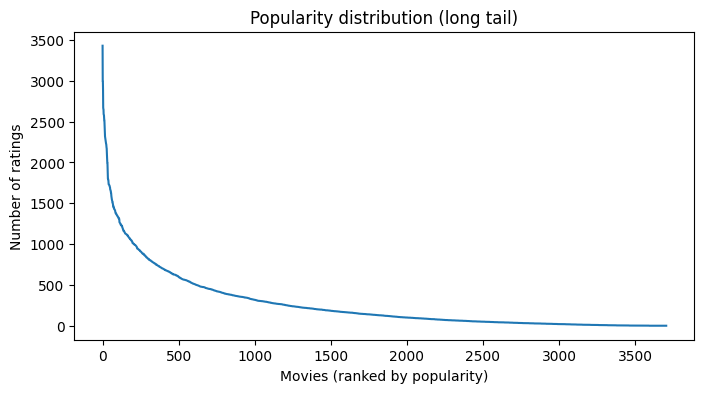

In [4]:
movie_counts = ratings["movie_id"].value_counts().sort_values(ascending=False)

n_top_20pct = int(len(movie_counts) * 0.2)
ratings_from_top_20pct = movie_counts.iloc[:n_top_20pct].sum()
pct_of_ratings = ratings_from_top_20pct / n_ratings

print(f"Top 20% of movies ({n_top_20pct} movies) account for {pct_of_ratings:.2%} of all ratings")

# quick visual
plt.figure(figsize=(8, 4))
plt.plot(movie_counts.values)
plt.xlabel("Movies (ranked by popularity)")
plt.ylabel("Number of ratings")
plt.title("Popularity distribution (long tail)")
plt.show()

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: count, dtype: float64

Min ratings per user: 20
Max ratings per user: 2314
Users with fewer than 5 ratings: 0


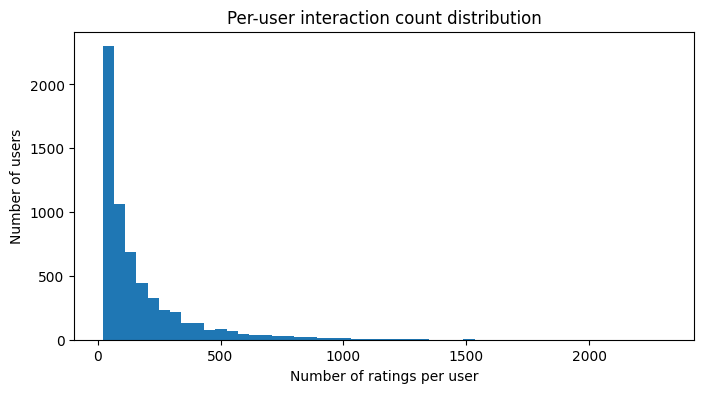

In [5]:
user_counts = ratings["user_id"].value_counts()

print(user_counts.describe())
print(f"\nMin ratings per user: {user_counts.min()}")
print(f"Max ratings per user: {user_counts.max()}")
print(f"Users with fewer than 5 ratings: {(user_counts < 5).sum()}")

plt.figure(figsize=(8, 4))
plt.hist(user_counts, bins=50)
plt.xlabel("Number of ratings per user")
plt.ylabel("Number of users")
plt.title("Per-user interaction count distribution")
plt.show()

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

Mean rating: 3.582


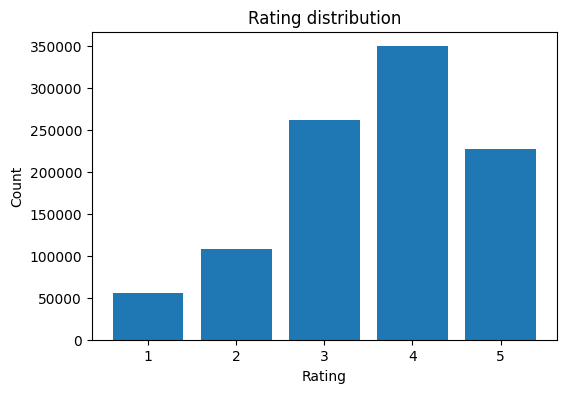

In [6]:
rating_dist = ratings["rating"].value_counts().sort_index()
print(rating_dist)
print(f"\nMean rating: {ratings['rating'].mean():.3f}")

plt.figure(figsize=(6, 4))
plt.bar(rating_dist.index, rating_dist.values)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating distribution")
plt.show()